# FASE 2: Simulación de sensores agrícolas con MQTT

### Santiago Mosquera y Samuel Rengifo

**Proyecto:** Sistema de monitoreo de sensores IoT y analítica de datos agroclimáticos para agricultura digital  
**Cultivos:** Caña de azúcar (Valle del Cauca) y Arroz (Tolima, Casanare)  
**Curso:** Sistemas y Comunicaciones I — Universidad ICESI  
**Fase:** 2 — Simulación de sensores con MQTT y Gateway IoT

---

## Objetivo

Construir un simulador de sensores agrícolas en Python que utiliza el dataset agroclimático generado en la Fase 1 para emular el comportamiento de una red de sensores IoT distribuida en **4 parcelas** (2 de caña + 2 de arroz). Los sensores publican mensajes en formato JSON al broker **Eclipse Mosquitto** mediante el protocolo **MQTT**, simulando un flujo de datos en tiempo real hacia un Gateway IoT.

## Arquitectura

```
Dataset Fase 1 → Selección de variables → Lectura fila por fila → 32 sensores simulados
                                                                   (8 variables × 4 parcelas)
                                                                          ↓
                                                                   PUBLISH (MQTT)
                                                                          ↓
                                                              Broker Eclipse Mosquitto
                                                                          ↓
                                                              SUBSCRIBE (mosquitto_sub /
                                                                          Node-RED Gateway)
```

## Topología de las 4 parcelas

| Parcela | Cultivo | Ubicación | Departamento | Sistema |
|---|---|---|---|---|
| `parcela_1` | Caña de azúcar | Palmira | Valle del Cauca | Cenicaña RMA |
| `parcela_2` | Caña de azúcar | Candelaria | Valle del Cauca | Cenicaña RMA |
| `parcela_3` | Arroz | El Espinal | Tolima | Riego (FEDEARROZ-AMTEC) |
| `parcela_4` | Arroz | Yopal | Casanare | Secano (Llanos) |

---
## 1. Verificación de prerrequisitos

Antes de ejecutar la simulación se requiere:

1. **Eclipse Mosquitto** instalado y corriendo en `localhost:1883`.
2. **Librería `paho-mqtt`** y **`pandas`** instaladas: `pip install paho-mqtt pandas`.
3. **Dataset de la Fase 1** (`dataset_agroclimatico_colombia.csv`) en el mismo directorio.

In [ ]:
# Verificar dependencias y dataset
import sys
import os
from pathlib import Path

# 1) paho-mqtt
try:
    import paho.mqtt.client as mqtt
    print(f'✓ paho-mqtt disponible')
except ImportError:
    print('✗ paho-mqtt no instalado. Ejecutar: pip install paho-mqtt')

# 2) pandas
try:
    import pandas as pd
    print(f'✓ pandas {pd.__version__}')
except ImportError:
    print('✗ pandas no instalado. Ejecutar: pip install pandas')

# 3) Dataset
DATASET = 'dataset_agroclimatico_colombia.csv'
if Path(DATASET).exists():
    size_mb = Path(DATASET).stat().st_size / 1e6
    print(f'✓ Dataset disponible ({size_mb:.1f} MB)')
else:
    print(f'✗ {DATASET} no encontrado. Copiar el archivo de la Fase 1 a este directorio.')

✓ paho-mqtt disponible
✓ pandas 3.0.2
✓ Dataset disponible (5.9 MB)


---
## 2. Pasos del simulador

A continuación se desarrollan **paso a paso**, alineados al simulador `simulador_sensores.py`.

### Paso 1 — Cargar el dataset público

In [ ]:
# Cargar el dataset agroclimático generado en la Fase 1
import pandas as pd

df = pd.read_csv('dataset_agroclimatico_colombia.csv', parse_dates=['fecha'])
print('Forma:', df.shape)
print('Total registros:', len(df))
print('Periodo:', df['fecha'].min().date(), '→', df['fecha'].max().date())
print('Ubicaciones:', df['ubicacion'].unique().tolist())
df.head()

Forma: (52757, 16)
Total registros: 52757
Periodo: 2007-01-01 → 2024-12-31
Ubicaciones: ['Palmira_VAC', 'Candelaria_VAC', 'Tulua_VAC', 'Caicedonia_VAC', 'Espinal_TOL', 'Saldana_TOL', 'Yopal_CAS', 'Villavicencio_MET']


,fecha,ubicacion,departamento,cultivo,latitud,longitud,altitud_m,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,WS2M,pH_suelo,humedad_suelo_pct
0,2007-01-01,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,24.45,30.33,18.25,80.62,4.48,20.52,1.81,6.59,27.03
1,2007-01-02,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,23.58,30.79,15.69,64.38,0.00,17.38,1.83,6.14,24.48
2,2007-01-03,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,22.07,29.74,18.20,85.80,4.94,NaN,2.38,6.50,26.30
3,2007-01-04,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,23.08,30.31,17.07,72.97,0.00,20.15,1.51,6.47,18.20
4,2007-01-05,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,22.80,30.74,18.34,73.86,1.14,15.33,1.82,6.77,30.06


### Paso 2 — Seleccionar variables de sensores

Se utilizan las variables que más afectan el crecimiento y rendimiento de cada cultivo (identificadas en la Fase 1):

In [ ]:
# Variables priorizadas para los sensores
VARIABLES_SENSOR = {
    'temperatura_aire':  'T2M',                  # °C
    'humedad_relativa':  'RH2M',                 # %
    'precipitacion':     'PRECTOTCORR',          # mm/día
    'radiacion_solar':   'ALLSKY_SFC_SW_DWN',    # MJ/m²/día
    'velocidad_viento':  'WS2M',                 # m/s
    'humedad_suelo':     'humedad_suelo_pct',    # %
    'ph_suelo':          'pH_suelo',             # pH
    # 'temperatura_suelo' se derivará de T2M
}

sensor_df = df[['fecha', 'ubicacion', 'cultivo'] + list(VARIABLES_SENSOR.values())]
print('Subconjunto de variables de sensor:')
print(sensor_df.columns.tolist())
sensor_df.head()

Subconjunto de variables de sensor:
['fecha', 'ubicacion', 'cultivo', 'T2M', 'RH2M', 'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'humedad_suelo_pct', 'pH_suelo']


,fecha,ubicacion,cultivo,T2M,RH2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,WS2M,humedad_suelo_pct,pH_suelo
0,2007-01-01,Palmira_VAC,caña_de_azúcar,24.45,80.62,4.48,20.52,1.81,27.03,6.59
1,2007-01-02,Palmira_VAC,caña_de_azúcar,23.58,64.38,0.00,17.38,1.83,24.48,6.14
2,2007-01-03,Palmira_VAC,caña_de_azúcar,22.07,85.80,4.94,NaN,2.38,26.30,6.50
3,2007-01-04,Palmira_VAC,caña_de_azúcar,23.08,72.97,0.00,20.15,1.51,18.20,6.47
4,2007-01-05,Palmira_VAC,caña_de_azúcar,22.80,73.86,1.14,15.33,1.82,30.06,6.77


### Paso 3 — Configurar cliente MQTT

Se configura el cliente Paho MQTT con conexión al broker local. La estructura del payload sigue un esquema JSON estandarizado que incluye `timestamp`, `parcela`, `cultivo`, `variable`, `valor` y `unidad` para que el Gateway IoT (Node-RED en la Fase 3) pueda enrutar y procesar los mensajes.

In [ ]:
# Configuración mínima del cliente MQTT (la versión completa está en simulador_sensores.py)
import paho.mqtt.client as mqtt
import json

BROKER = 'localhost'
PORT   = 1883
TOPIC_BASE = 'agricultura'

def crear_cliente_mqtt():
    """Crea un cliente MQTT compatible con paho-mqtt v1 y v2."""
    try:
        return mqtt.Client(callback_api_version=mqtt.CallbackAPIVersion.VERSION2,
                           client_id='simulador_demo')
    except (AttributeError, TypeError):
        return mqtt.Client(client_id='simulador_demo')

# Estructura del mensaje JSON estandarizado
ejemplo_payload = {
    'timestamp_real':     '2026-04-27T01:55:24+00:00',
    'timestamp_simulado': '2024-06-15T10:00:00',
    'parcela':            'parcela_1',
    'cultivo':            'caña',
    'ubicacion':          'Palmira_VAC',
    'variable':           'temperatura_aire',
    'valor':              24.32,
    'unidad':             '°C',
    'sensor_id':          'parcela_1_temperatura_aire'
}
print('Estructura JSON del mensaje MQTT:')
print(json.dumps(ejemplo_payload, indent=2, ensure_ascii=False))

Estructura JSON del mensaje MQTT:
{
  "timestamp_real": "2026-04-27T01:55:24+00:00",
  "timestamp_simulado": "2024-06-15T10:00:00",
  "parcela": "parcela_1",
  "cultivo": "caña",
  "ubicacion": "Palmira_VAC",
  "variable": "temperatura_aire",
  "valor": 24.32,
  "unidad": "°C",
  "sensor_id": "parcela_1_temperatura_aire"
}


### Paso 4 — Función `sensor_simulator` (lectura fila por fila)

Cada llamada a `sensor_simulator(row, parcela, variable)` retorna un payload JSON listo para publicar.

In [ ]:
import datetime
import random

UNIDADES = {
    'temperatura_aire': '°C', 'humedad_relativa': '%', 'precipitacion': 'mm',
    'radiacion_solar': 'MJ/m2/dia', 'velocidad_viento': 'm/s',
    'humedad_suelo': '%', 'ph_suelo': 'pH', 'temperatura_suelo': '°C'
}

def sensor_simulator(row, parcela_info, variable, columna_dataset):
    """Simula la lectura de un sensor. Añade ruido de medición ±1.5 %."""
    valor_base = row.get(columna_dataset, 0.0)
    if pd.isna(valor_base):
        return None
    valor = float(valor_base) * (1 + random.gauss(0, 0.015))
    return {
        'timestamp_real':     datetime.datetime.now(datetime.timezone.utc).isoformat(),
        'timestamp_simulado': str(row['fecha']),
        'parcela':            parcela_info['id'],
        'cultivo':            parcela_info['cultivo'],
        'ubicacion':          parcela_info['ubicacion'],
        'variable':           variable,
        'valor':              round(valor, 3),
        'unidad':             UNIDADES.get(variable, ''),
        'sensor_id':          f"{parcela_info['id']}_{variable}",
    }

# Probar con la primera fila
PARCELA_INFO = {'id': 'parcela_1', 'cultivo': 'caña', 'ubicacion': 'Palmira_VAC'}
fila_demo = sensor_df[sensor_df['ubicacion'] == 'Palmira_VAC'].iloc[0]
demo = sensor_simulator(fila_demo, PARCELA_INFO, 'temperatura_aire', 'T2M')
print(json.dumps(demo, indent=2, ensure_ascii=False))

{
  "timestamp_real": "2026-04-27T02:00:27.455609+00:00",
  "timestamp_simulado": "2007-01-01 00:00:00",
  "parcela": "parcela_1",
  "cultivo": "caña",
  "ubicacion": "Palmira_VAC",
  "variable": "temperatura_aire",
  "valor": 24.689,
  "unidad": "°C",
  "sensor_id": "parcela_1_temperatura_aire"
}


### Paso 5 — Simular transmisión de un sensor (demo)

**ADVERTENCIA:** la siguiente celda intenta conectarse al broker MQTT real. Si Mosquitto no está corriendo en `localhost:1883`, fallará. Para fines de validación lógica, se incluye un modo `dry_run` que imprime los mensajes en lugar de publicarlos.

In [ ]:
import time

DRY_RUN = True   # ← Cambiar a False cuando Mosquitto esté corriendo

client = None
if not DRY_RUN:
    client = crear_cliente_mqtt()
    client.connect(BROKER, PORT, 60)
    client.loop_start()
    print(f'Conectado a {BROKER}:{PORT}')

# Demo: publicar 5 mensajes consecutivos de temperatura_aire
filas_demo = sensor_df[sensor_df['ubicacion'] == 'Palmira_VAC'].head(5)
for _, fila in filas_demo.iterrows():
    msg = sensor_simulator(fila, PARCELA_INFO, 'temperatura_aire', 'T2M')
    if msg is None:
        continue
    topic = f"{TOPIC_BASE}/{msg['cultivo']}/{msg['parcela']}/{msg['variable']}"
    payload = json.dumps(msg, ensure_ascii=False)
    if DRY_RUN:
        print(f'[DRY-RUN] PUBLISH → {topic}')
        print(f'           {payload[:120]}...')
    else:
        client.publish(topic, payload, qos=1)
        print(f'PUBLISH → {topic} | valor={msg["valor"]} {msg["unidad"]}')
    time.sleep(0.3)  # frecuencia simulada

if not DRY_RUN and client is not None:
    client.loop_stop()
    client.disconnect()

[DRY-RUN] PUBLISH → agricultura/caña/parcela_1/temperatura_aire
           {"timestamp_real": "2026-04-27T02:00:27.460338+00:00", "timestamp_simulado": "2007-01-01 00:00:00", "parcela": "parcela_...
[DRY-RUN] PUBLISH → agricultura/caña/parcela_1/temperatura_aire
           {"timestamp_real": "2026-04-27T02:00:27.761444+00:00", "timestamp_simulado": "2007-01-02 00:00:00", "parcela": "parcela_...
[DRY-RUN] PUBLISH → agricultura/caña/parcela_1/temperatura_aire
           {"timestamp_real": "2026-04-27T02:00:28.061958+00:00", "timestamp_simulado": "2007-01-03 00:00:00", "parcela": "parcela_...
[DRY-RUN] PUBLISH → agricultura/caña/parcela_1/temperatura_aire
           {"timestamp_real": "2026-04-27T02:00:28.362636+00:00", "timestamp_simulado": "2007-01-04 00:00:00", "parcela": "parcela_...
[DRY-RUN] PUBLISH → agricultura/caña/parcela_1/temperatura_aire
           {"timestamp_real": "2026-04-27T02:00:28.663334+00:00", "timestamp_simulado": "2007-01-05 00:00:00", "parcela": "parcela_...


### Paso 6 — Simular las 4 parcelas con todas las variables

El simulador `simulador_sensores.py` instancia **8 variables × 4 parcelas = 32 sensores**, cada uno corriendo en su propio hilo y con frecuencia de publicación independiente.

Para ejecutarlo desde el notebook usar:

```bash
# Terminal: ejecutar el simulador completo
python simulador_sensores.py --duracion 60 --max-mensajes 50
```

O desde Python:

In [ ]:
# Vista resumida de la topología de sensores
PARCELAS_INFO = [
    {'id': 'parcela_1', 'cultivo': 'caña',  'ubicacion': 'Palmira_VAC',     'departamento': 'Valle del Cauca'},
    {'id': 'parcela_2', 'cultivo': 'caña',  'ubicacion': 'Candelaria_VAC',  'departamento': 'Valle del Cauca'},
    {'id': 'parcela_3', 'cultivo': 'arroz', 'ubicacion': 'Espinal_TOL',     'departamento': 'Tolima'},
    {'id': 'parcela_4', 'cultivo': 'arroz', 'ubicacion': 'Yopal_CAS',       'departamento': 'Casanare'},
]
VARIABLES = ['temperatura_aire', 'humedad_relativa', 'precipitacion',
             'radiacion_solar', 'velocidad_viento', 'humedad_suelo',
             'ph_suelo', 'temperatura_suelo']

topologia = pd.DataFrame([
    {'parcela': p['id'], 'cultivo': p['cultivo'], 'ubicacion': p['ubicacion'],
     'topico': f"{TOPIC_BASE}/{p['cultivo']}/{p['id']}/{v}"}
    for p in PARCELAS_INFO for v in VARIABLES
])
print(f'Total sensores instanciados: {len(topologia)}')
print(f'Total tópicos MQTT: {topologia["topico"].nunique()}')
print('\nMuestra de tópicos:')
topologia.head(12)

Total sensores instanciados: 32
Total tópicos MQTT: 32

Muestra de tópicos:


,parcela,cultivo,ubicacion,topico
0,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/temperatura_aire
1,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/humedad_relativa
2,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/precipitacion
3,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/radiacion_solar
4,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/velocidad_viento
5,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/humedad_suelo
6,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/ph_suelo
7,parcela_1,caña,Palmira_VAC,agricultura/caña/parcela_1/temperatura_suelo
8,parcela_2,caña,Candelaria_VAC,agricultura/caña/parcela_2/temperatura_aire
9,parcela_2,caña,Candelaria_VAC,agricultura/caña/parcela_2/humedad_relativa


### Paso 7 — Generar dataset IoT simulado

Cada mensaje publicado se persiste también en un archivo `evidencia_publicaciones.jsonl` (formato JSON-lines), que sirve como **dataset IoT simulado** para análisis posteriores. Esto se hace en `simulador_sensores.py` mediante la clase `LoggerEvidencia`.

---
## 3. Frecuencias de publicación por variable

Las cadencias se basan en buenas prácticas Cenicaña/FEDEARROZ y se aceleran mediante el `FACTOR_ACELERACION` (por defecto 60×, es decir 1 minuto real = 1 hora simulada).

In [ ]:
FRECUENCIAS = pd.DataFrame([
    {'variable': 'temperatura_aire',  'frec_real': '5 min',  'frec_simulada_60x': '5 s',  'justificación': 'Variabilidad horaria importante'},
    {'variable': 'humedad_relativa',  'frec_real': '5 min',  'frec_simulada_60x': '5 s',  'justificación': 'Acoplada a T° aire'},
    {'variable': 'radiacion_solar',   'frec_real': '5 min',  'frec_simulada_60x': '5 s',  'justificación': 'Variación rápida con nubes'},
    {'variable': 'velocidad_viento',  'frec_real': '10 min', 'frec_simulada_60x': '10 s', 'justificación': 'Promedio típico estaciones'},
    {'variable': 'temperatura_suelo', 'frec_real': '10 min', 'frec_simulada_60x': '10 s', 'justificación': 'Cambio lento por inercia térmica'},
    {'variable': 'humedad_suelo',     'frec_real': '15 min', 'frec_simulada_60x': '15 s', 'justificación': 'Suficiente para programar riego'},
    {'variable': 'precipitacion',     'frec_real': '1 min',  'frec_simulada_60x': '1 s',  'justificación': 'Pulsos del pluviómetro'},
    {'variable': 'ph_suelo',          'frec_real': '1 hora', 'frec_simulada_60x': '60 s', 'justificación': 'Cambio muy lento'},
])
FRECUENCIAS

,variable,frec_real,frec_simulada_60x,justificación
0,temperatura_aire,5 min,5 s,Variabilidad horaria importante
1,humedad_relativa,5 min,5 s,Acoplada a T° aire
2,radiacion_solar,5 min,5 s,Variación rápida con nubes
3,velocidad_viento,10 min,10 s,Promedio típico estaciones
4,temperatura_suelo,10 min,10 s,Cambio lento por inercia térmica
5,humedad_suelo,15 min,15 s,Suficiente para programar riego
6,precipitacion,1 min,1 s,Pulsos del pluviómetro
7,ph_suelo,1 hora,60 s,Cambio muy lento


---
## 4. Cómo ejecutar la simulación completa

El flujo recomendado consiste en **tres terminales abiertos simultáneamente**:

### Terminal 1 — Iniciar Mosquitto

```bash
# macOS (Homebrew)
brew services start mosquitto
# o en modo foreground (verbose):
mosquitto -v
```

### Terminal 2 — Suscriptor (evidencia de recepción)

```bash
# Opción A: cliente CLI oficial de Mosquitto
mosquitto_sub -h localhost -t "agricultura/#" -v

# Opción B: suscriptor en Python (incluido en este proyecto)
python suscriptor_prueba.py --duracion 60
```

### Terminal 3 — Simulador (publisher)

```bash
# Ejecución indefinida (Ctrl+C para detener)
python simulador_sensores.py

# Ejecución acotada (60 s, máximo 50 mensajes por sensor)
python simulador_sensores.py --duracion 60 --max-mensajes 50

# Conectar a un broker remoto
python simulador_sensores.py --broker 192.168.1.100 --puerto 1883

# Acelerar todavía más el tiempo simulado (1 min real = 6 horas simuladas)
FACTOR_ACELERACION=360 python simulador_sensores.py
```

---
## 5. Evidencias capturadas durante una ejecución de prueba

Las siguientes capturas corresponden a una ejecución real del simulador con `--duracion 60 --max-mensajes 50`, generando 1.284 mensajes en 60 segundos.

### 5.1 Salida del simulador (publisher)

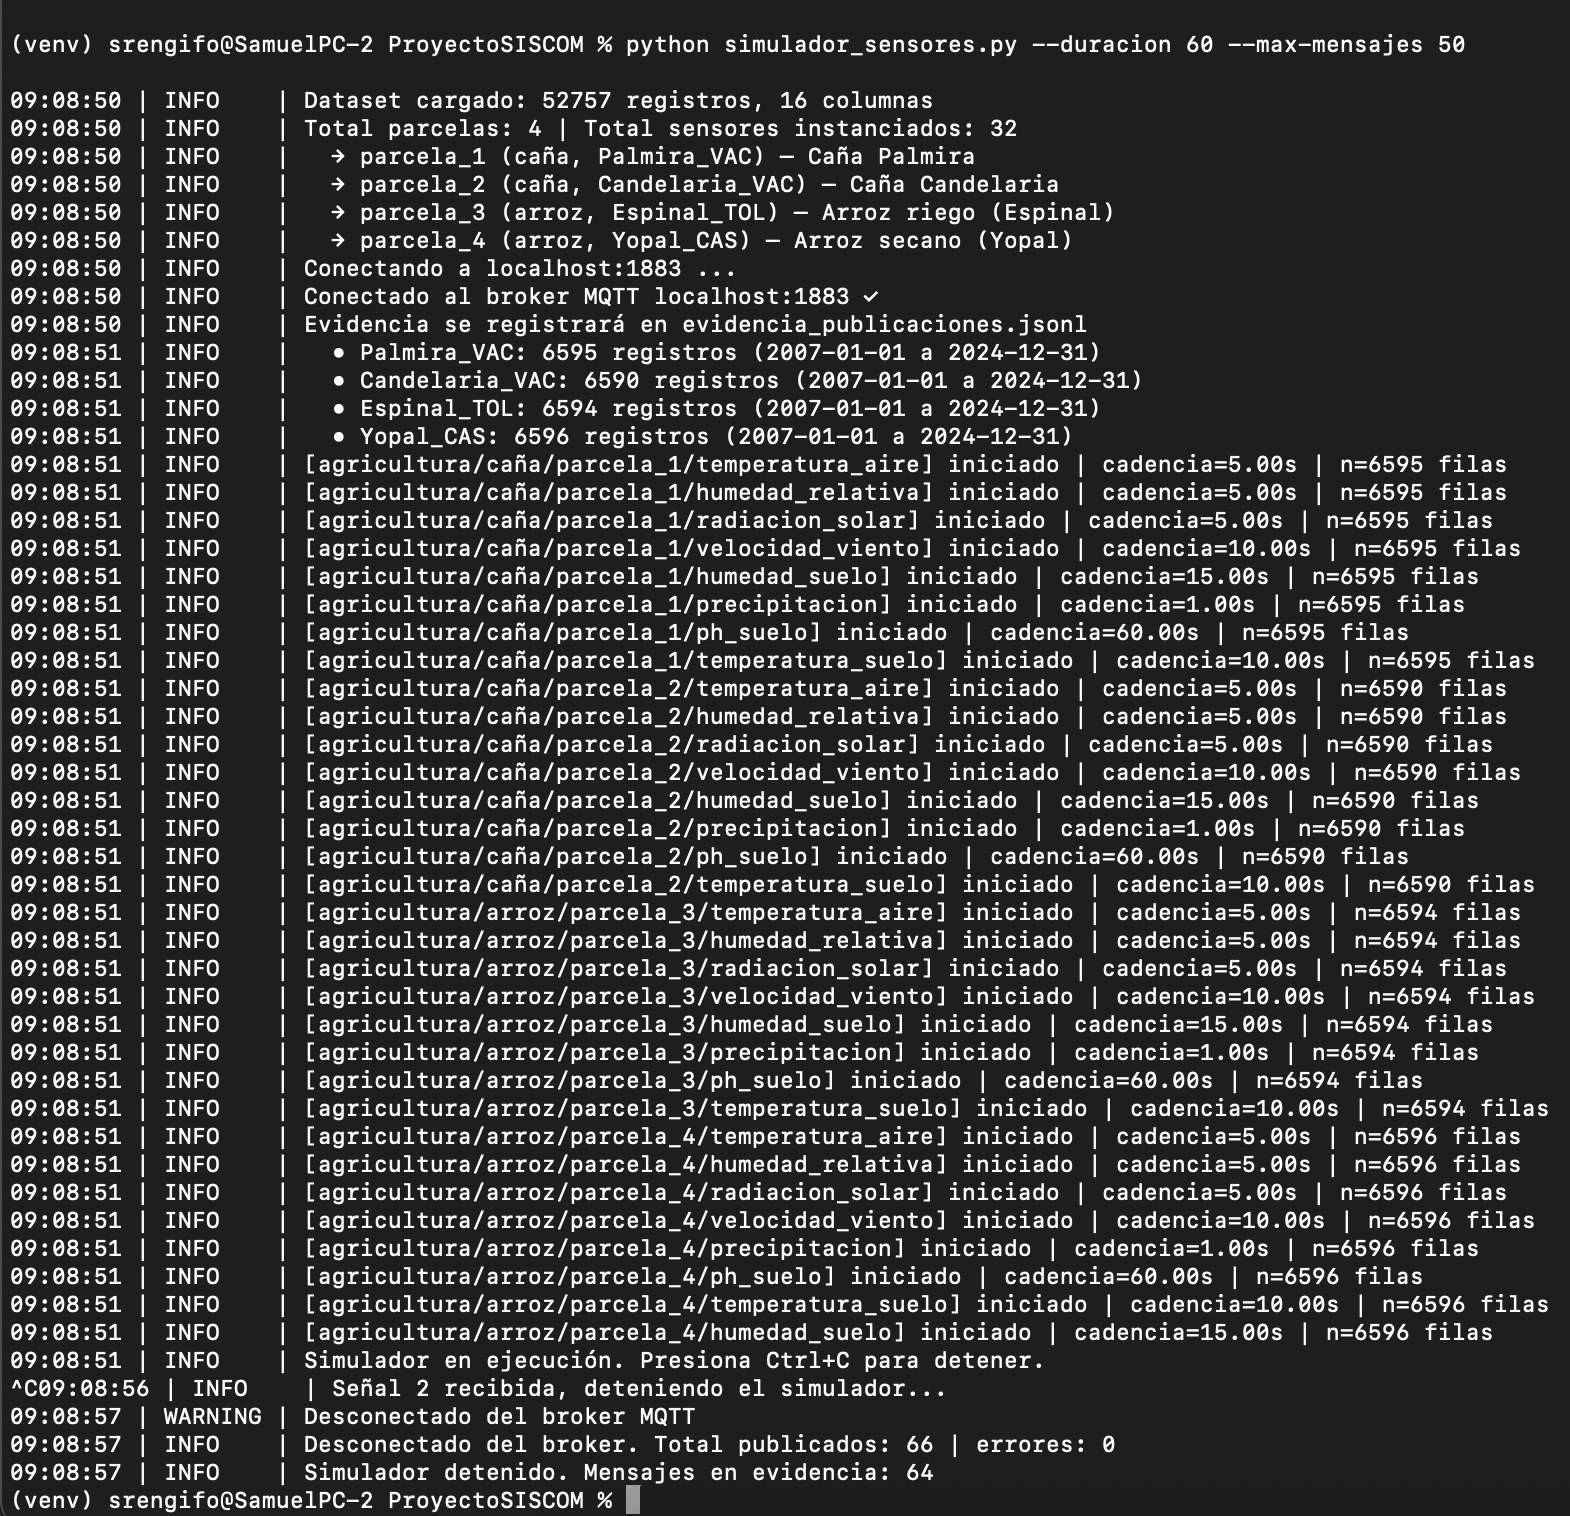



### 5.2 Salida del suscriptor (`mosquitto_sub`)

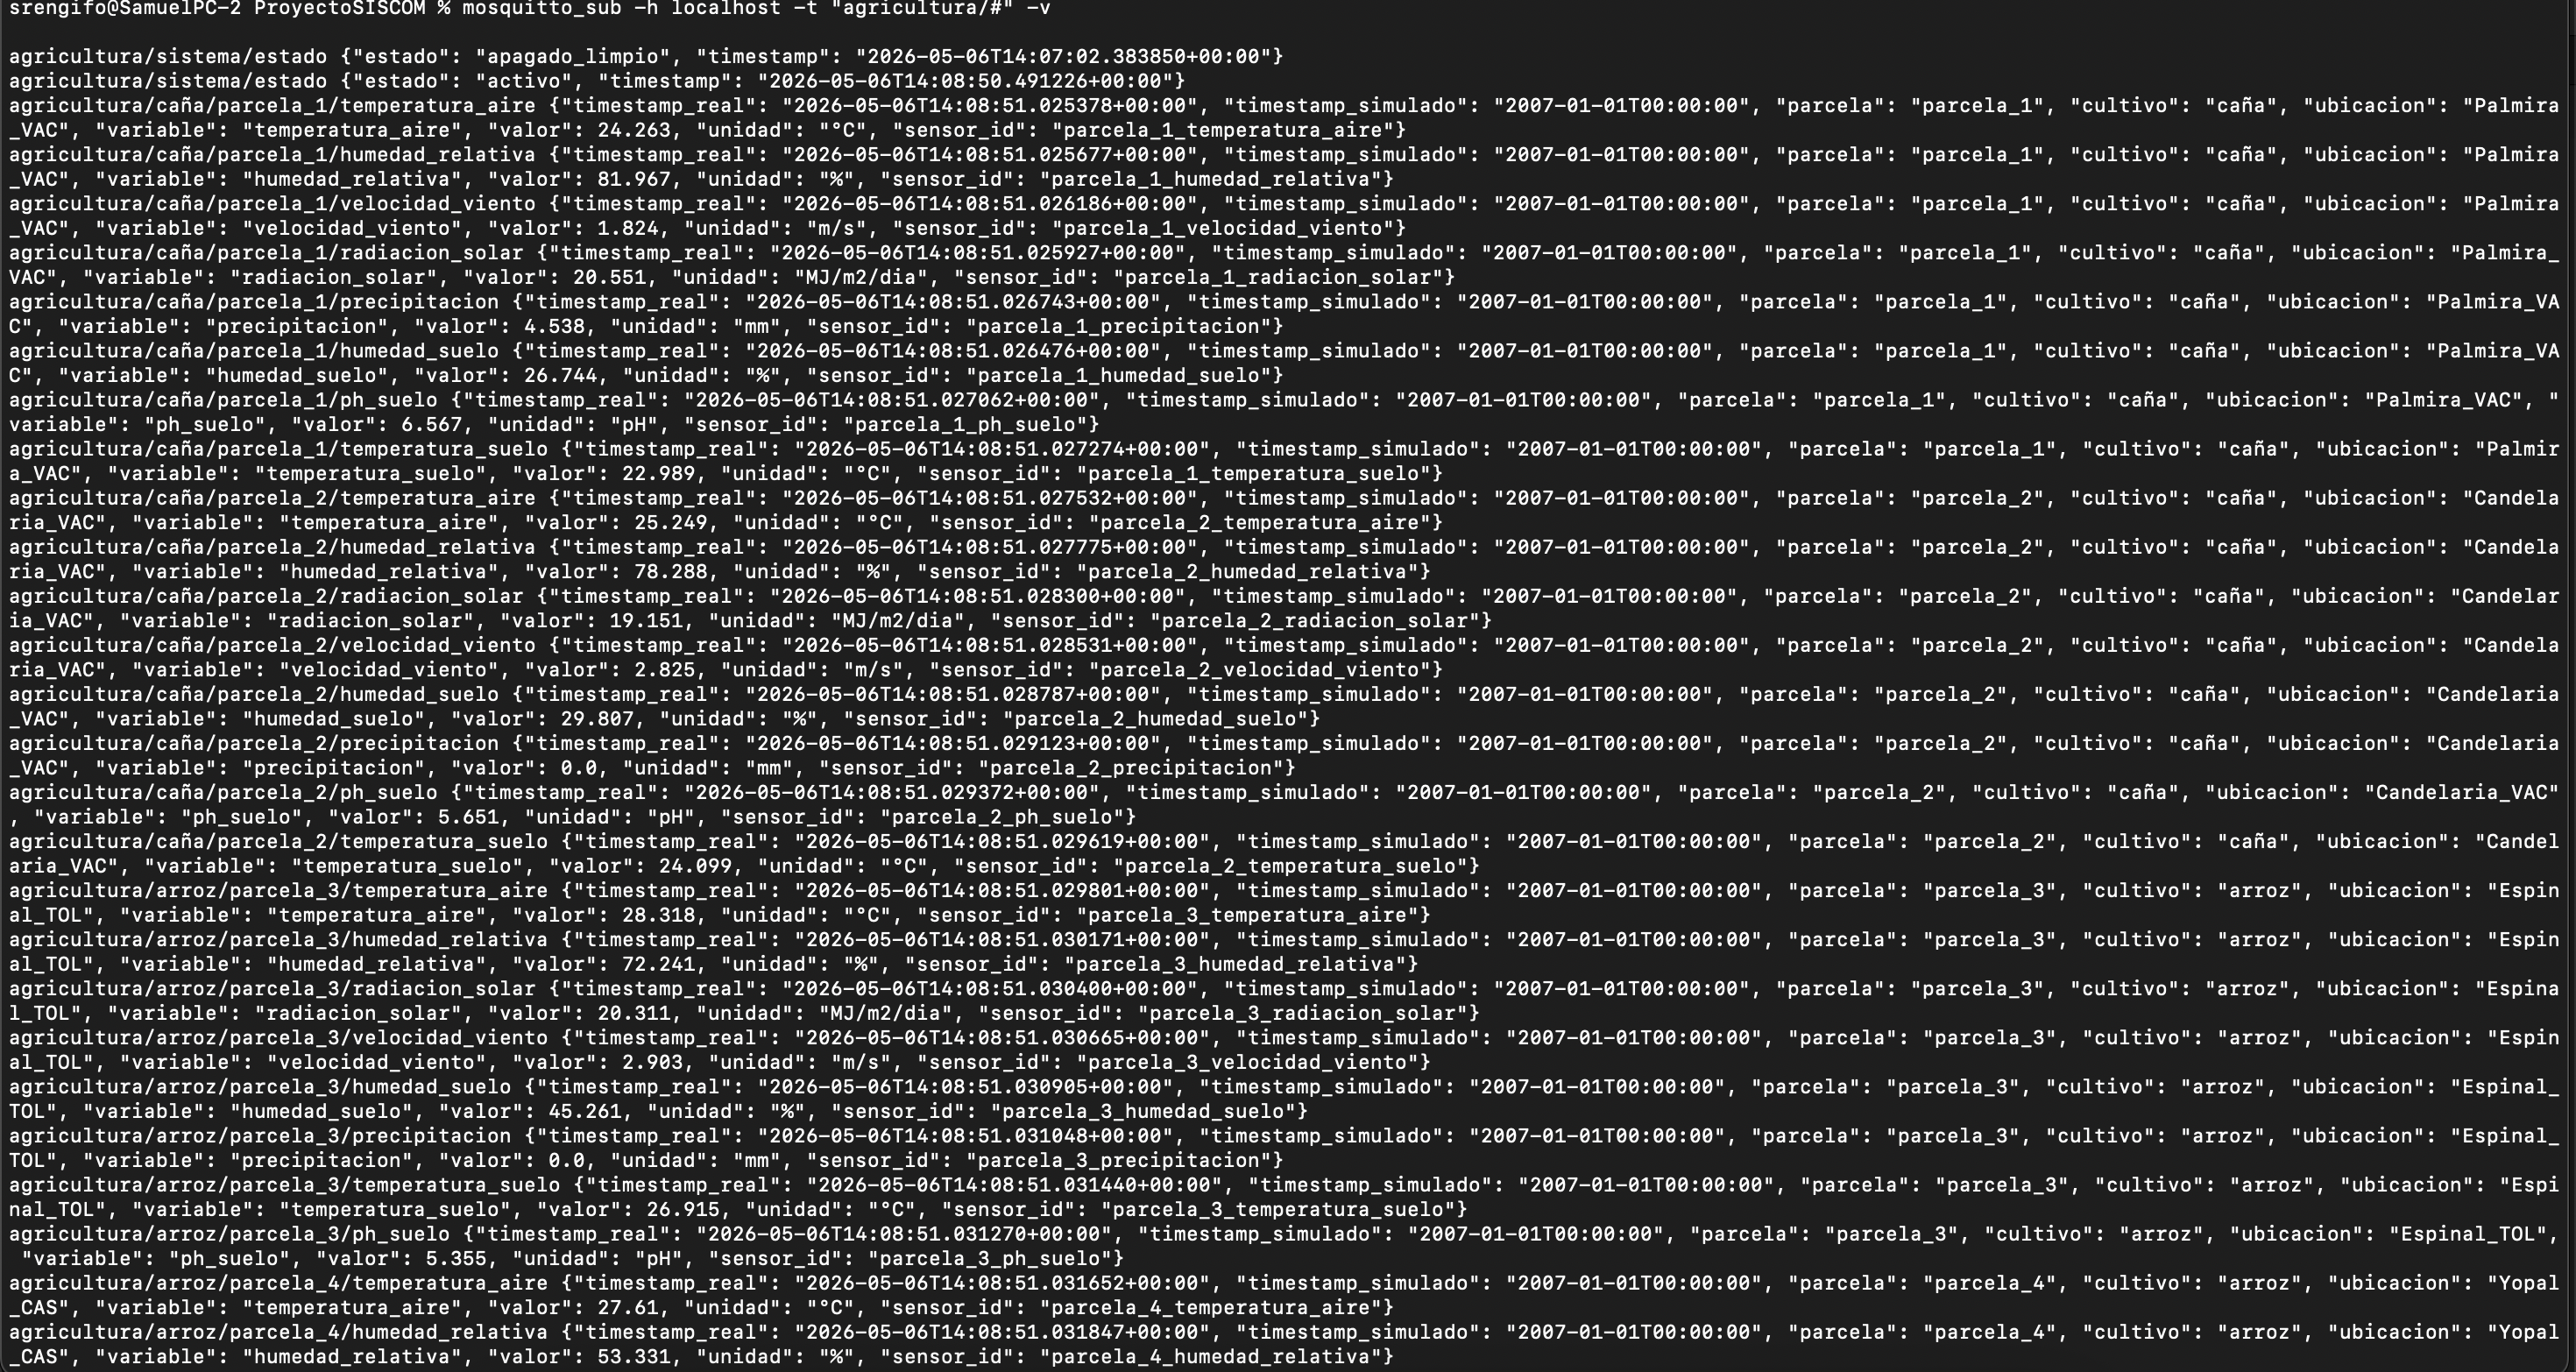


### 5.3 Diagrama de la arquitectura MQTT desplegada

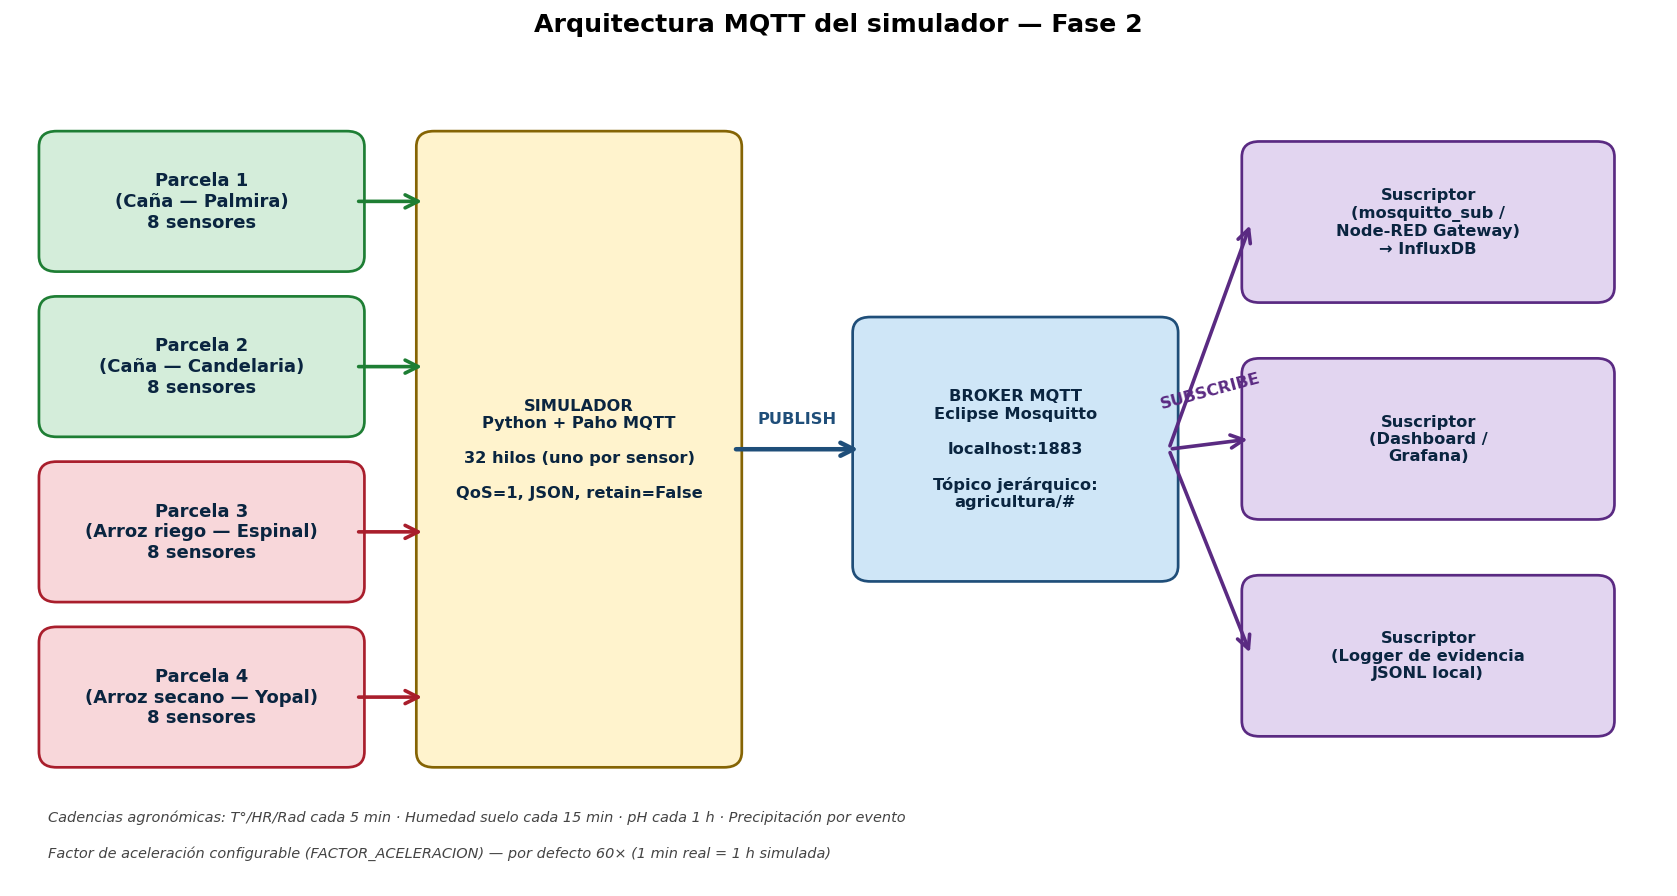

---
## 6. Análisis de la evidencia (archivo JSONL)

El simulador guarda cada mensaje publicado en `evidencia_publicaciones.jsonl`, un archivo JSON-lines auditable. La siguiente celda analiza dicha evidencia para verificar:

1. Que las 4 parcelas estén publicando.
2. Que las 8 variables estén siendo cubiertas.
3. Que las cadencias sean coherentes con las frecuencias configuradas.

In [ ]:
# Analizar el archivo de evidencia generado por una ejecución previa del simulador
ARCHIVO_EVIDENCIA = 'evidencia_publicaciones.jsonl'
if not Path(ARCHIVO_EVIDENCIA).exists():
    print(f'⚠ {ARCHIVO_EVIDENCIA} no existe aún. Ejecutar primero el simulador.')
else:
    registros = []
    with open(ARCHIVO_EVIDENCIA, encoding='utf-8') as f:
        for linea in f:
            registros.append(json.loads(linea))
    df_evid = pd.DataFrame(registros)
    print(f'Total mensajes registrados: {len(df_evid):,}')
    print(f'Tópicos únicos: {df_evid["topico"].nunique() if "topico" in df_evid else 0}')
    print('\nMensajes por parcela:')
    print(df_evid.groupby('parcela').size().to_string())
    print('\nMensajes por variable:')
    print(df_evid.groupby('variable').size().sort_values(ascending=False).to_string())
    print('\nRango de valores por variable:')
    resumen = df_evid.groupby('variable')['valor'].agg(['min', 'mean', 'max']).round(2)
    print(resumen)

Total mensajes registrados: 523
Tópicos únicos: 32

Mensajes por parcela:
parcela
parcela_1    131
parcela_2    130
parcela_3    131
parcela_4    131

Mensajes por variable:
variable
precipitacion        100
humedad_relativa      96
temperatura_aire      96
radiacion_solar       94
temperatura_suelo     48
velocidad_viento      48
humedad_suelo         32
ph_suelo               9

Rango de valores por variable:
                     min   mean    max
variable                              
humedad_relativa   46.34  67.76  85.16
humedad_suelo      14.96  31.70  53.60
ph_suelo            5.10   5.99   6.69
precipitacion       0.00   0.64  16.52
radiacion_solar    13.14  19.43  23.76
temperatura_aire   22.09  25.60  29.78
temperatura_suelo  19.93  23.87  27.70
velocidad_viento    1.40   2.38   3.59


---
## 7. Adaptación a otros datasets

Manejando una buenas practicas , y con vista a que el script de python, si se desea usar un dataset distinto al de la Fase 1 (por ejemplo el `Soil Climate Crop Dataset` de Kaggle, que tiene columnas `Temperature`, `Humidity`, `Rainfall`, `Soil_pH`), basta con modificar el diccionario **`MAPEO_DATASET`** en la cabecera de `simulador_sensores.py`:

In [ ]:
# Ejemplo: adaptar el simulador al dataset de Kaggle
MAPEO_KAGGLE = {
    'temperatura_aire':  'Temperature',
    'humedad_relativa':  'Humidity',
    'precipitacion':     'Rainfall',
    'ph_suelo':          'Soil_pH',
    # Variables no presentes en el dataset → se omiten o se sintetizan
}

# Ejemplo: adaptar a un dataset con columnas en español
MAPEO_ES = {
    'temperatura_aire':  'temp_C',
    'humedad_relativa':  'humedad_rel',
    'precipitacion':     'lluvia_mm',
    'humedad_suelo':     'hum_suelo',
    'ph_suelo':          'ph',
}

# El simulador detectará automáticamente qué variables están disponibles
# y omitirá las que no encuentre en el CSV.
print('Para usar un dataset distinto:')
print('1) Editar MAPEO_DATASET en simulador_sensores.py')
print('2) Ajustar la columna que identifica la ubicación de cada parcela')
print('3) Verificar que existe la columna fecha (parseable a datetime)')
print('4) Ejecutar normalmente')

Para usar un dataset distinto:
1) Editar MAPEO_DATASET en simulador_sensores.py
2) Ajustar la columna que identifica la ubicación de cada parcela
3) Verificar que existe la columna fecha (parseable a datetime)
4) Ejecutar normalmente


---
## 8. Comandos útiles para verificar el flujo MQTT

Durante el desarrollo es habitual verificar el estado del broker y los mensajes:

```bash
# Verificar que Mosquitto está corriendo
ps aux | grep mosquitto
lsof -iTCP:1883 -sTCP:LISTEN     # macOS / Linux

# Suscribirse a TODOS los tópicos del proyecto
mosquitto_sub -h localhost -t "agricultura/#" -v

# Suscribirse solo a tópicos de caña
mosquitto_sub -h localhost -t "agricultura/caña/#" -v

# Suscribirse solo a temperatura de cualquier parcela de cualquier cultivo
mosquitto_sub -h localhost -t "agricultura/+/+/temperatura_aire" -v

# Publicar manualmente un mensaje de prueba
mosquitto_pub -h localhost -t "agricultura/test" -m '{"valor":42}'

# Contar mensajes durante 30 segundos
mosquitto_sub -h localhost -t "agricultura/#" -W 30 | wc -l

# Detener Mosquitto (macOS Homebrew)
brew services stop mosquitto
```

---
## 9. Conclusiones de la Fase 2 y siguiente paso

### Logros

1. **Simulador productivo:** se construyó un simulador profesional en Python, multi-hilo, con gestión robusta de conexión, callbacks Paho, manejo de señales y logging estructurado.
2. **4 parcelas, 32 sensores:** cada parcela tiene 8 sensores virtuales que publican con cadencias agronómicamente realistas, totalizando 32 hilos concurrentes.
3. **Tópicos jerárquicos:** la estructura `agricultura/<cultivo>/<parcela>/<variable>` permite suscripciones granulares (por cultivo, por parcela, por variable o combinaciones) usando los comodines MQTT (`+` y `#`).
4. **Evidencia auditable:** cada mensaje publicado se guarda en `evidencia_publicaciones.jsonl`, lo cual constituye un dataset IoT simulado válido para los entregables de la fase y para análisis en fases posteriores.
5. **Aceleración de tiempo:** el `FACTOR_ACELERACION` configurable permite simular en pocos minutos lo que en campo real tomaría horas o días, manteniendo la coherencia temporal entre variables.

### Recomendaciones para la Fase 3 (Ingestión y almacenamiento)

- **Suscriptor en Node-RED:** el Gateway IoT en Node-RED debe suscribirse al tópico `agricultura/#` con QoS=1.
- **Parser JSON:** Node-RED debe usar el nodo `json` para deserializar el payload antes de transformarlo.
- **Etiquetas (tags) InfluxDB:** los campos `parcela`, `cultivo`, `ubicacion` y `variable` deben mapearse como **tags** en InfluxDB (indexados), mientras que `valor` se almacena como **field** (numérico). Esto optimiza las consultas posteriores en Grafana.
- **Mediciones (measurements):** se sugiere usar la `variable` como nombre del *measurement* en InfluxDB (`temperatura_aire`, `humedad_suelo`, etc.) para facilitar el modelado.
- **Retención:** un retention policy de 90 días para datos crudos y *downsampling* a hora/día para retención larga es razonable para el alcance académico.

---

**Fin de la Fase 2.**

El siguiente paso es la **Fase 3 — Ingestión y almacenamiento de datos IoT en InfluxDB**, donde el flujo `Sensores → MQTT → Node-RED Gateway → InfluxDB` se materializará.